# Atlanta MSA Population Forecast: Three Demographic Models

## A Comprehensive Guide to Population Projections

This notebook demonstrates three distinct approaches to forecasting population for the Atlanta Metropolitan Statistical Area (MSA) from 2025 to 2035:

1. **Component Extrapolation** — A simple model based on historical demographic rates
2. **ARIMA Time-Series** — A statistical time-series model for exponential growth
3. **Cohort-Component Model** — A detailed demographic model tracking age-specific populations

Each model has different strengths, assumptions, and appropriate use cases. This notebook will guide you through the mathematics, code logic, and interpretation of results.

---

## Section 0: Setup and Data Loading

### Step 0.1: Import Libraries

We begin by importing all necessary Python libraries for data manipulation, statistical analysis, and visualization.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Configuration
excel_file = '/Users/pranavlakhotia/Downloads/Final_Data_for_Modeling.xlsx'

print(f"Loading data from: {excel_file}")
print("✓ All libraries imported successfully")

Loading data from: /Users/pranavlakhotia/Downloads/Final_Data_for_Modeling.xlsx
✓ All libraries imported successfully


### Step 0.2: Load and Explore Data

We load three Excel sheets containing:

- **pop_estimate_components**: Annual population estimates and demographic components (births, deaths, migration)
- **pop_by_agesex**: Age-sex structured population for years 2019-2024
- **mortality_rate_2020_census**: Age-specific death rates from 2020 Census

Filter for **Atlanta MSA (CBSA 12060)** only.


In [2]:
# Load Excel file
xls = pd.ExcelFile(excel_file)
print(f"Available sheets: {xls.sheet_names}\n")

# Load all sheets
pop_estimate_components = pd.read_excel(excel_file, sheet_name='pop_estimate_components')
pop_by_agesex = pd.read_excel(excel_file, sheet_name='pop_by_agesex')
mortality_rate_2020_census = pd.read_excel(excel_file, sheet_name='mortality_rate_2020_census')

# Filter for Atlanta MSA (CBSA 12060)
pop_estimate_components = pop_estimate_components[pop_estimate_components["CBSA"] == 12060].copy()
pop_by_agesex = pop_by_agesex[pop_by_agesex["CBSA"] == 12060].copy()

# Map YEAR codes to calendar years (1=2019, 2=2020, ..., 6=2024)
pop_by_agesex["YEAR"] = pop_by_agesex["YEAR"] + 2018

print("✓ Data loaded and filtered for Atlanta MSA\n")
print(f"pop_estimate_components: {pop_estimate_components.shape}")
print(f"Columns: {list(pop_estimate_components.columns)}\n")
print(f"pop_by_agesex: {pop_by_agesex.shape}")
print(f"Columns: {list(pop_by_agesex.columns)}\n")
print("Sample of pop_estimate_components (last 5 rows):")
display(pop_estimate_components[['YEAR', 'POP_ESTIMATE', 'BIRTHS', 'DEATHS', 'NET_MIG']].tail())

Available sheets: ['pop_estimate_components', 'pop_by_agesex', 'mortality_rate_2020_census']

✓ Data loaded and filtered for Atlanta MSA

pop_estimate_components: (26, 12)
Columns: ['CBSA', 'NAME', 'YEAR', 'POP_ESTIMATE', 'NPOPCHG', 'BIRTHS', 'DEATHS', 'NATURAL_CHANGE', 'INTERNATIONAL_MIG', 'DOMESTIC_MIG', 'NET_MIG', 'RESIDUAL']

pop_by_agesex: (516, 14)
Columns: ['SUMLEV', 'CBSA', 'MDIV', 'NAME', 'LSAD', 'YEAR', 'AGE', 'TOT_POP', 'TOT_MALE', 'TOT_FEMALE', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

Sample of pop_estimate_components (last 5 rows):


,YEAR,POP_ESTIMATE,BIRTHS,DEATHS,NET_MIG
21,2021,6160335,68161,50821.0,21532.0
22,2022,6250876,71118,51240.0,71640.0
23,2023,6333350,71340,46054.0,57003.0
24,2024,6420229,71057,45896.0,61487.0
25,2025,6482182,71442,45973.0,36418.0


---

## Section 1: Model Selection and Overview

### Why Three Models?

Population projections can be approached from different angles:

| **Criterion** | **Model 1: Extrapolation** | **Model 2: ARIMA** | **Model 3: Cohort-Component** |
|---|---|---|---|
| **Approach** | Demographic components | Statistical time-series | Age-structured cohorts |
| **Data Required** | Annual aggregates | Time series only | Age-sex structure + components |
| **Interpretability** | High (rates are intuitive) | Low (black-box) | Very high (demographic meaning) |
| **Age Structure** | No | No | Yes (crucial feature) |
| **Mortality Detail** | No | No | Yes (by age) |
| **Complexity** | Low | Medium | High |
| **Best For** | Quick estimates, stable trends | Short-term smoothing | Long-term planning with detail |

**Recommendation**: Use **Model 3 (Cohort-Component)** for planning because it preserves demographic structure. Models 1 and 2 demonstrate alternative approaches and serve as sensitivity checks.

---

## Section 2: Time Series Preprocessing

### Step 2.1: Prepare Data and Convert to Rates

Population dynamics are driven by four components:

$$
\text{Population Change} = \text{Births} - \text{Deaths} + \text{Net Migration} + \text{Residual}
$$

To make these components comparable over time and across demographics, we **normalize by population** to create **rates**:

$$
b_t = \frac{B_t}{P_t} \quad \text{(birth rate)}
$$

$$
d_t = \frac{D_t}{P_t} \quad \text{(death rate)}
$$

$$
m_{int,t} = \frac{IM_t}{P_t} \quad \text{(international migration rate)}
$$

$$
m_{dom,t} = \frac{DM_t}{P_t} \quad \text{(domestic migration rate)}
$$

$$
r_t = \frac{R_t}{P_t} \quad \text{(residual rate)}
$$

**Why rates instead of counts?**
- Raw birth counts depend on population size; rates are population-independent
- Rates are more stable over time and less affected by one-time population shocks
- Rates are transferable to different population structures


In [3]:
# Prepare time series and convert counts to rates
df = pop_estimate_components.copy()
df = df.sort_values("YEAR").reset_index(drop=True)

print(f"Time series period: {df['YEAR'].min()} to {df['YEAR'].max()}")
print(f"Total observations: {len(df)}\n")

# Calculate RATES (normalized by population)
df["birth_rate"] = df["BIRTHS"] / df["POP_ESTIMATE"]
df["death_rate"] = df["DEATHS"] / df["POP_ESTIMATE"]
df["int_mig_rate"] = df["INTERNATIONAL_MIG"] / df["POP_ESTIMATE"]
df["dom_mig_rate"] = df["DOMESTIC_MIG"] / df["POP_ESTIMATE"]
df["res_rate"] = df["RESIDUAL"] / df["POP_ESTIMATE"]

print("✓ Rates calculated (counts ÷ population)")
print("\nSample rates (per capita) - last 3 years:")
display(df[['YEAR', 'birth_rate', 'death_rate', 'int_mig_rate', 'dom_mig_rate']].tail(3))

Time series period: 2000 to 2025
Total observations: 26

✓ Rates calculated (counts ÷ population)

Sample rates (per capita) - last 3 years:


,YEAR,birth_rate,death_rate,int_mig_rate,dom_mig_rate
23,2023,0.011264,0.007272,0.006449,0.002552
24,2024,0.011068,0.007149,0.009928,-0.000351
25,2025,0.011021,0.007092,0.005152,0.000466


### Step 2.2: Rolling Window Analysis

Instead of using rates from a single recent year, we compute a **rolling window** over the last 10 years to smooth out short-term fluctuations. For each rate $r$, we calculate:

$$
\mu_r = \text{mean}(r_t) \quad \text{over last 10 years}
$$

$$
\sigma_r = \text{std}(r_t) \quad \text{over last 10 years}
$$

**Why 10 years?**
- Captures recent demographic trends (not too distant past)
- Smooths business cycles (e.g., 2008 recession, post-pandemic migration shifts)
- Provides ~25 observations for reliable statistics
- Avoids overfitting to a single year's anomaly

**Key insight**: The rolling window mean $\mu_r$ becomes our **baseline assumption** for projections. The standard deviation $\sigma_r$ measures historical variability.


In [4]:
# Apply rolling window (10-year) to compute mean and std
window = 10
rates = ["birth_rate", "death_rate", "int_mig_rate", "dom_mig_rate", "res_rate"]

means = {}
stds = {}

for r in rates:
    means[r] = df[r].rolling(window).mean().iloc[-1]
    stds[r] = df[r].rolling(window).std().iloc[-1]

print(f"Rolling window size: {window} years")
print(f"Rolling window period: {df['YEAR'].iloc[-window]} to {df['YEAR'].iloc[-1]}\n")
print("Mean and Std of demographic rates (last 10 years):")
print("-" * 70)
for r in rates:
    print(f"  {r:18s}  μ = {means[r]:10.6f}  σ = {stds[r]:10.6f}")
print("-" * 70)

Rolling window size: 10 years
Rolling window period: 2016 to 2025

Mean and Std of demographic rates (last 10 years):
----------------------------------------------------------------------
  birth_rate          μ =   0.011664  σ =   0.000624
  death_rate          μ =   0.007156  σ =   0.000670
  int_mig_rate        μ =   0.004164  σ =   0.002710
  dom_mig_rate        μ =   0.003652  σ =   0.002367
  res_rate            μ =   0.000019  σ =   0.000080
----------------------------------------------------------------------


---

# MODEL 1: COMPONENT EXTRAPOLATION

## Concept: Simple Demographic Rate Projection

This model projects population forward using a **single constant growth rate** $g$ that combines all demographic components. It's the simplest approach but sacrifices demographic detail.

### Step 1.1: Calculate Total Growth Rate

The **population balance equation** states:

$$
P_{t+1} = P_t + B_t - D_t + NM_t
$$

Dividing by $P_t$:

$$
\frac{P_{t+1}}{P_t} = 1 + b_t - d_t + m_t
$$

We define the **growth rate** as:

$$
g = b - d + m_{int} + m_{dom} + r
$$

where all components are rates (per capita). Using rolling window means:

$$
g = \mu_b - \mu_d + \mu_{m_{int}} + \mu_{m_{dom}} + \mu_r
$$

### Step 1.2: Calculate Uncertainty (Variance Propagation)

Since demographic events are somewhat independent, **variance adds**:

$$
\sigma_g^2 = \sigma_b^2 + \sigma_d^2 + \sigma_{int}^2 + \sigma_{dom}^2 + \sigma_r^2
$$

$$
\sigma_g = \sqrt{\sum_i \sigma_i^2}
$$

**Key principle**: Uncertainties compound under independence. This is NOT the mean of standard deviations—we sum their squares.


In [5]:
# MODEL 1: COMPONENT EXTRAPOLATION
print("=" * 70)
print("MODEL 1: COMPONENT EXTRAPOLATION")
print("=" * 70)

# Calculate total growth rate and uncertainty via variance propagation
var_total = sum(stds[r]**2 for r in rates)
sigma_g = np.sqrt(var_total)

g = (means["birth_rate"] - means["death_rate"] + 
     means["int_mig_rate"] + means["dom_mig_rate"] + means["res_rate"])

print(f"\nTotal growth rate g:         {g:12.6f} (per capita per year)")
print(f"Total uncertainty σ_g:       {sigma_g:12.6f}")
print(f"\nInterpretation:")
print(f"  • Population grows at {g*100:.3f}% per year on average")
print(f"  • ±1σ range: [{(g-sigma_g)*100:.3f}%, {(g+sigma_g)*100:.3f}%]")
print(f"  • ±2σ range: [{(g-2*sigma_g)*100:.3f}%, {(g+2*sigma_g)*100:.3f}%] (95% CI)")

# Extract baseline 
last_year = df["YEAR"].iloc[-1]
last_pop = df["POP_ESTIMATE"].iloc[-1]
print(f"\nBaseline year: {int(last_year)}")
print(f"Baseline population: {last_pop:,.0f}")

MODEL 1: COMPONENT EXTRAPOLATION

Total growth rate g:             0.012343 (per capita per year)
Total uncertainty σ_g:           0.003714

Interpretation:
  • Population grows at 1.234% per year on average
  • ±1σ range: [0.863%, 1.606%]
  • ±2σ range: [0.492%, 1.977%] (95% CI)

Baseline year: 2025
Baseline population: 6,482,182


### Step 1.3: Projection Loop with Time-Dependent Uncertainty

The **recursive projection formula** is:

$$
P_{t+1} = P_t \cdot (1 + g)
$$

After $t$ years, uncertainty compounds as:

$$
\sigma_t = \sigma_g \cdot \sqrt{t}
$$

Confidence intervals at time t:
- **67% CI** (±1σ): $[P_t (1 - \sigma_t), P_t (1 + \sigma_t)]$
- **95% CI** (±2σ): $[P_t (1 - 2\sigma_t), P_t (1 + 2\sigma_t)]$

**Why** $\sqrt{t}$? Each year adds independent noise. After $t$ independent draws, the cumulative variability grows as $\sqrt{t}$ (standard result from probability theory).


In [8]:
# MODEL 1: PROJECT (Component Extrapolation)
print("\nProjection: 10-year forward (2025-2035)")
print("-" * 70)

forecast_years = 10
results_model1 = []
current_pop = last_pop

for i in range(1, forecast_years + 1):
    year = last_year + i
    next_pop = current_pop * (1 + g)
    
    # Time-dependent uncertainty
    sigma_t = sigma_g * np.sqrt(i)
    
    # Population confidence intervals
    pop_1s_up = next_pop * (1 + sigma_t)
    pop_1s_low = next_pop * (1 - sigma_t)
    pop_2s_up = next_pop * (1 + 2 * sigma_t)
    pop_2s_low = next_pop * (1 - 2 * sigma_t)
    
    # Component point estimates
    births = next_pop * means["birth_rate"]
    deaths = next_pop * means["death_rate"]
    int_mig = next_pop * means["int_mig_rate"]
    dom_mig = next_pop * means["dom_mig_rate"]
    residual = next_pop * means["res_rate"]
    
    results_model1.append({
        "YEAR": int(year),
        "POP_ESTIMATE": next_pop,
        "POP_1S_LOW": pop_1s_low,
        "POP_1S_UP": pop_1s_up,
        "POP_2S_LOW": pop_2s_low,
        "POP_2S_UP": pop_2s_up,
        "BIRTHS": births,
        "DEATHS": deaths,
        "INT_MIG": int_mig,
        "DOM_MIG": dom_mig,
        "RESIDUAL": residual
    })
    
    current_pop = next_pop

model1_df = pd.DataFrame(results_model1)
print("\nModel 1 Results (select years):")
print(model1_df[["YEAR", "POP_2S_LOW", "POP_1S_LOW", "POP_ESTIMATE", "POP_1S_UP",  "POP_2S_UP"]].iloc[::1].to_string(index=False))


Projection: 10-year forward (2025-2035)
----------------------------------------------------------------------

Model 1 Results (select years):
 YEAR   POP_2S_LOW   POP_1S_LOW  POP_ESTIMATE    POP_1S_UP    POP_2S_UP
 2026 6.513450e+06 6.537821e+06  6.562193e+06 6.586565e+06 6.610937e+06
 2027 6.573407e+06 6.608300e+06  6.643192e+06 6.678084e+06 6.712977e+06
 2028 6.638667e+06 6.681929e+06  6.725190e+06 6.768452e+06 6.811714e+06
 2029 6.707059e+06 6.757630e+06  6.808201e+06 6.858772e+06 6.909343e+06
 2030 6.777761e+06 6.834999e+06  6.892236e+06 6.949474e+06 7.006712e+06
 2031 6.850359e+06 6.913834e+06  6.977309e+06 7.040784e+06 7.104259e+06
 2032 6.924618e+06 6.994025e+06  7.063432e+06 7.132838e+06 7.202245e+06
 2033 7.000387e+06 7.075502e+06  7.150617e+06 7.225732e+06 7.300847e+06
 2034 7.077569e+06 7.158224e+06  7.238879e+06 7.319534e+06 7.400189e+06
 2035 7.156096e+06 7.242163e+06  7.328230e+06 7.414297e+06 7.500364e+06


### Step 1.4: Visualization - Model 1 Forecast

Plot historical population (2000-2024) and 10-year forecast (2025-2035) with confidence bands showing uncertainty growth over time.


MODEL 1: VISUALIZATION


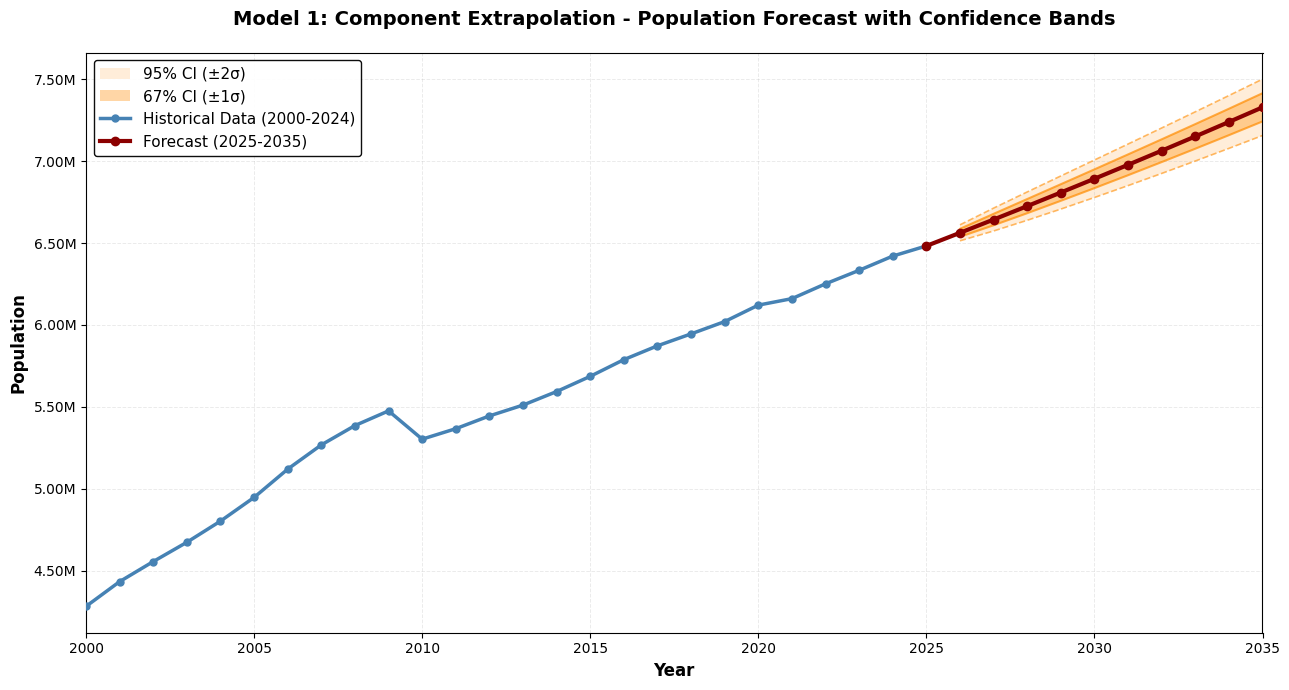


✓ Model 1 visualization saved as 'model1_forecast.png'

Key Insights:
  • 2035 Forecast: 7,328,230
  • 67% CI (±1σ): 7,242,163 to 7,414,297
  • 95% CI (±2σ): 7,156,096 to 7,500,364
  • Uncertainty grows as √t (widening bands over time)


In [19]:
# MODEL 1 VISUALIZATION
print("\n" + "=" * 70)
print("MODEL 1: VISUALIZATION")
print("=" * 70)

fig, ax = plt.subplots(figsize=(13, 7))

# Historical data
hist_years = df["YEAR"].values
hist_pop = df["POP_ESTIMATE"].values

# Plot confidence bands FIRST (95% CI outer, then 67% CI inner)
# 95% Confidence Interval (±2σ) - lighter shade
ax.fill_between(model1_df["YEAR"], model1_df["POP_2S_LOW"], model1_df["POP_2S_UP"], 
                alpha=0.15, color='darkorange', label='95% CI (±2σ)', zorder=1, edgecolor='none')

# 67% Confidence Interval (±1σ) - darker shade
ax.fill_between(model1_df["YEAR"], model1_df["POP_1S_LOW"], model1_df["POP_1S_UP"], 
                alpha=0.35, color='darkorange', label='67% CI (±1σ)', zorder=2, edgecolor='none')

# Add border lines for the bands to make them more distinct
ax.plot(model1_df["YEAR"], model1_df["POP_2S_LOW"], '--', color='darkorange', linewidth=1.2, alpha=0.6, zorder=2)
ax.plot(model1_df["YEAR"], model1_df["POP_2S_UP"], '--', color='darkorange', linewidth=1.2, alpha=0.6, zorder=2)
ax.plot(model1_df["YEAR"], model1_df["POP_1S_LOW"], '-', color='darkorange', linewidth=1.5, alpha=0.7, zorder=2)
ax.plot(model1_df["YEAR"], model1_df["POP_1S_UP"], '-', color='darkorange', linewidth=1.5, alpha=0.7, zorder=2)

# Plot historical data
ax.plot(hist_years, hist_pop, 'o-', color='steelblue', linewidth=2.5, markersize=5, label='Historical Data (2000-2024)', zorder=4)

# Plot forecast point estimate with smooth connection to historical data
forecast_years_extended = np.concatenate([[hist_years[-1]], model1_df["YEAR"].values])
forecast_pop_extended = np.concatenate([[hist_pop[-1]], model1_df["POP_ESTIMATE"].values])
ax.plot(forecast_years_extended, forecast_pop_extended, 'o-', color='darkred', linewidth=3, markersize=6, label='Forecast (2025-2035)', zorder=5)

# Formatting
ax.set_title('Model 1: Component Extrapolation - Population Forecast with Confidence Bands', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Population', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.7)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95, edgecolor='black', fancybox=True)

# Set x-axis limits
ax.set_xlim(2000, 2035)

plt.tight_layout()
plt.savefig('model1_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Model 1 visualization saved as 'model1_forecast.png'")
print(f"\nKey Insights:")
print(f"  • 2035 Forecast: {model1_df.iloc[-1]['POP_ESTIMATE']:,.0f}")
print(f"  • 67% CI (±1σ): {model1_df.iloc[-1]['POP_1S_LOW']:,.0f} to {model1_df.iloc[-1]['POP_1S_UP']:,.0f}")
print(f"  • 95% CI (±2σ): {model1_df.iloc[-1]['POP_2S_LOW']:,.0f} to {model1_df.iloc[-1]['POP_2S_UP']:,.0f}")
print(f"  • Uncertainty grows as √t (widening bands over time)")

---

# MODEL 2: ARIMA TIME-SERIES

## Concept: Statistical Autoregressive Model

ARIMA (AutoRegressive Integrated Moving Average) is a classic time-series model that learns patterns from historical data without explicit demographic reasoning. It's useful for smoothing and short-term forecasts but treats population as a "black box."

### Step 2.1: Log-Transform for Exponential Growth

Population typically grows **exponentially** (not linearly). We log-transform to linearize:

$$
Y_t = \log(P_t)
$$

Then: $$P_t = e^{Y_t}$$

**Advantage**: Linear models work better on log-scale data. Forecast variability is naturally symmetric on the original population scale.


### Step 2.2: Stationarity Testing (Augmented Dickey-Fuller Test)

A time series is **stationary** if its mean and variance don't change over time. ARIMA models require stationarity.

**ADF Test Null Hypothesis (H₀)**: Series is non-stationary (has unit root)

**Reject H₀ if p-value < 0.05** → Series is stationary

We test the **original log-population series** and (if needed) apply **first differencing**:

$$
\Delta Y_t = Y_t - Y_{t-1}
$$

Differencing removes trends and usually achieves stationarity.


In [9]:
# MODEL 2: ARIMA
print("\n" + "=" * 70)
print("MODEL 2: ARIMA (Log-Transformed Population)")
print("=" * 70)

# Build time series with log transform
ts_df = df.copy()
ts_df["log_pop"] = np.log(ts_df["POP_ESTIMATE"])
series = ts_df["log_pop"]

# Test 1: ADF on original log-population
print("\n--- STEP 1: ADF Test on Original Log-Population ---")
adf_original = adfuller(series)
print(f"ADF Statistic:    {adf_original[0]:.6f}")
print(f"P-value:          {adf_original[1]:.6f}")
print(f"Result:           {'Non-stationary (p > 0.05)' if adf_original[1] > 0.05 else 'Stationary (p < 0.05)'}")

# Apply first differencing
ts_diff = series.diff().dropna()
print("\n--- STEP 2: ADF Test After First Differencing ---")
adf_diff = adfuller(ts_diff)
print(f"ADF Statistic:    {adf_diff[0]:.6f}")
print(f"P-value:          {adf_diff[1]:.2e}")
print(f"Result:           {'Non-stationary (p > 0.05)' if adf_diff[1] > 0.05 else 'Stationary (p < 0.05)'}")
print(f"\n→ Using d=1 (first difference) to achieve stationarity")


MODEL 2: ARIMA (Log-Transformed Population)

--- STEP 1: ADF Test on Original Log-Population ---
ADF Statistic:    1.015989
P-value:          0.994432
Result:           Non-stationary (p > 0.05)

--- STEP 2: ADF Test After First Differencing ---
ADF Statistic:    -5.843231
P-value:          3.73e-07
Result:           Stationary (p < 0.05)

→ Using d=1 (first difference) to achieve stationarity


### Step 2.3: ARIMA(1,1,0) Model

The notation ARIMA(p, d, q) means:
- **p=1**: AutoRegressive order (use 1 past value)
- **d=1**: Differencing order (first difference)
- **q=0**: Moving-Average order (no MA component)

The model is fitted on first differences:

$$
\Delta Y_t = \phi \cdot \Delta Y_{t-1} + \varepsilon_t
$$

Where:
- $\phi$ = autoregressive coefficient (estimated from data)
- $\varepsilon_t$ = white noise innovation (random error)

**Forecast**: Recursively apply the AR relation to generate future values, then back-transform from log-space to population.


In [11]:
# Fit ARIMA(1,1,0)
print("\n--- STEP 3: Fit ARIMA(1,1,0) Model ---")
model = ARIMA(series, order=(1, 1, 0))
model_fit = model.fit()

print(f"\nModel Summary (overview):")
print(f"AIC: {model_fit.aic:.2f}")
print(f"BIC: {model_fit.bic:.2f}")
print(f"Log-Likelihood: {model_fit.llf:.2f}")

# Extract AR coefficient
phi = model_fit.params['ar.L1']
print(f"\nEstimated Parameters:")
print(f"  φ (AR coefficient):  {phi:.4f}")
print(f"\nInterpretation:")
print(f"  • AR coefficient φ = {phi:.4f} (< 1, process is stable)")
print(f"  • Past growth influences current growth")


--- STEP 3: Fit ARIMA(1,1,0) Model ---

Model Summary (overview):
AIC: -140.05
BIC: -137.62
Log-Likelihood: 72.03

Estimated Parameters:
  φ (AR coefficient):  0.7822

Interpretation:
  • AR coefficient φ = 0.7822 (< 1, process is stable)
  • Past growth influences current growth


### Step 2.4: 10-Step Ahead Forecast

We generate forecasts in log-space, then **back-transform** to population levels:

$$
P_t = e^{Y_t}
$$

The ARIMA model provides both point forecasts and 95% confidence intervals in log-space. Back-transforming preserves the intervals (though they become asymmetric on the original scale).


In [15]:
print("\n--- STEP 4: Generate 10-Step Forecast (2025-2035) ---")

# Forecast steps ahead
forecast_steps = 10
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

# Back-transform from log-space to population levels
forecast_df["POP_ESTIMATE"] = np.exp(forecast_df["mean"])
forecast_df["LOWER_95"] = np.exp(forecast_df["mean_ci_lower"])
forecast_df["UPPER_95"] = np.exp(forecast_df["mean_ci_upper"])

# Attach calendar years
start_year = int(ts_df["YEAR"].iloc[-1]) + 1
future_years = list(range(start_year, start_year + forecast_steps))
forecast_df["YEAR"] = future_years

model2_df = forecast_df[["YEAR", "POP_ESTIMATE", "LOWER_95", "UPPER_95"]].copy()
model2_df.reset_index(drop=True, inplace=True)

print("\nModel 2 Results (select years):")
print(model2_df.iloc[::1].to_string(index=False))


--- STEP 4: Generate 10-Step Forecast (2025-2035) ---

Model 2 Results (select years):
 YEAR  POP_ESTIMATE     LOWER_95     UPPER_95
 2026  6.531055e+06 6.362880e+06 6.703675e+06
 2027  6.569539e+06 6.228483e+06 6.929269e+06
 2028  6.599797e+06 6.079533e+06 7.164582e+06
 2029  6.623560e+06 5.926712e+06 7.402342e+06
 2030  6.642207e+06 5.775882e+06 7.638472e+06
 2031  6.656828e+06 5.630183e+06 7.870677e+06
 2032  6.668286e+06 5.491185e+06 8.097713e+06
 2033  6.677262e+06 5.359535e+06 8.318974e+06
 2034  6.684291e+06 5.235341e+06 8.534258e+06
 2035  6.689794e+06 5.118407e+06 8.743608e+06


### Step 2.5: Visualization - Model 2 Forecast

Plot historical log-transformed population and the ARIMA forecast with 95% confidence intervals in original population scale.


MODEL 2: VISUALIZATION


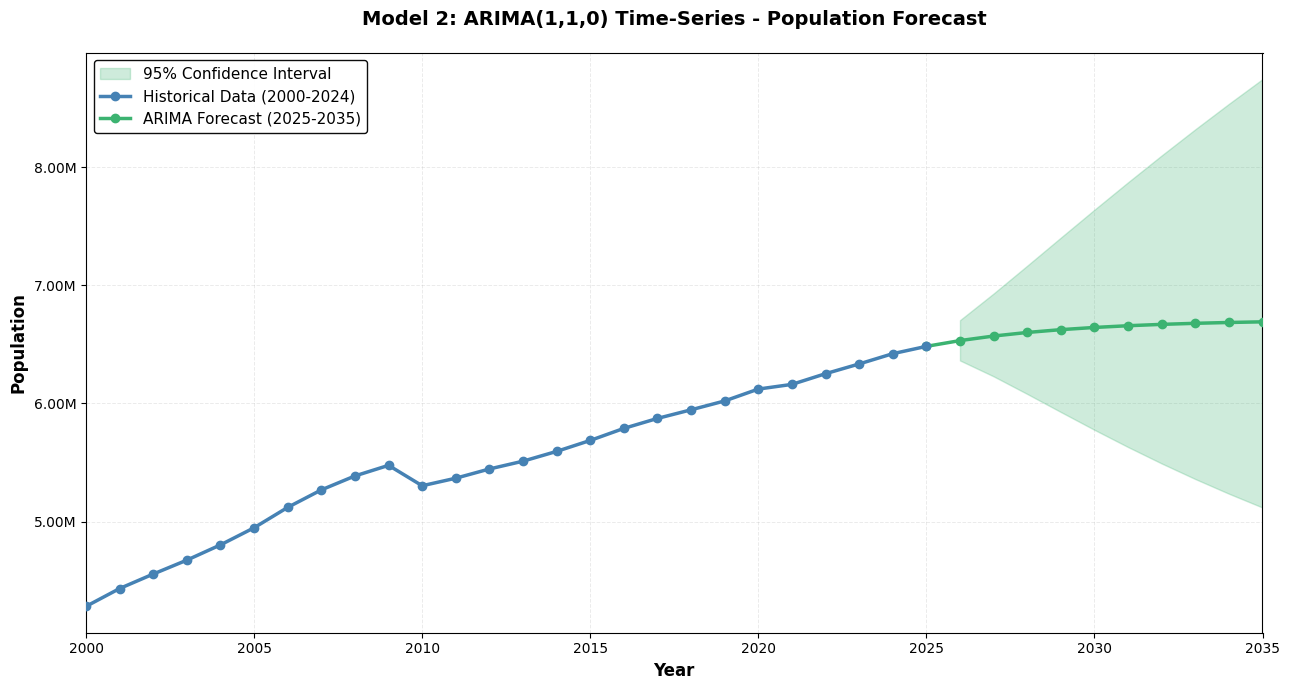


✓ Model 2 visualization saved as 'model2_forecast.png'

Key Insights:
  • 2035 Forecast: 6,689,794
  • 95% CI Range: 5,118,407 to 8,743,608
  • CI widens substantially due to short time series (26 years)
  • Model treats population as 'black box' - no demographic interpretation


In [20]:
# MODEL 2 VISUALIZATION
print("\n" + "=" * 70)
print("MODEL 2: VISUALIZATION")
print("=" * 70)

fig, ax = plt.subplots(figsize=(13, 7))

# Historical data
hist_years = df["YEAR"].values
hist_pop = df["POP_ESTIMATE"].values

# Plot confidence band first
ax.fill_between(model2_df["YEAR"], model2_df["LOWER_95"], model2_df["UPPER_95"], 
                alpha=0.25, color='mediumseagreen', label='95% Confidence Interval', zorder=2)

# Plot historical data
ax.plot(hist_years, hist_pop, 'o-', color='steelblue', linewidth=2.5, markersize=6, label='Historical Data (2000-2024)', zorder=4)

# Plot forecast with smooth connection to historical data
forecast_years_extended = np.concatenate([[hist_years[-1]], model2_df["YEAR"].values])
forecast_pop_extended = np.concatenate([[hist_pop[-1]], model2_df["POP_ESTIMATE"].values])
ax.plot(forecast_years_extended, forecast_pop_extended, 'o-', color='mediumseagreen', linewidth=2.5, markersize=6, label='ARIMA Forecast (2025-2035)', zorder=3)

# Formatting
ax.set_title('Model 2: ARIMA(1,1,0) Time-Series - Population Forecast', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Population', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.7)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95, edgecolor='black', fancybox=True)

# Set x-axis limits
ax.set_xlim(2000, 2035)

plt.tight_layout()
plt.savefig('model2_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Model 2 visualization saved as 'model2_forecast.png'")
print(f"\nKey Insights:")
print(f"  • 2035 Forecast: {model2_df.iloc[-1]['POP_ESTIMATE']:,.0f}")
print(f"  • 95% CI Range: {model2_df.iloc[-1]['LOWER_95']:,.0f} to {model2_df.iloc[-1]['UPPER_95']:,.0f}")
print(f"  • CI widens substantially due to short time series (26 years)")
print(f"  • Model treats population as 'black box' - no demographic interpretation")

---

# MODEL 3: COHORT-COMPONENT MODEL

## Concept: Age-Structured Demographic Projection

This is the **gold standard for population forecasting**. It tracks each age cohort separately through time, accounting for:
- Age-specific fertility
- Age-specific mortality  
- Age-weighted migration
- Cohort aging (each cohort moves up one age per year)

### Core Identity: The Cohort Equation

For each age $x$ and year $t$:

$$
P(x, t+1) = P(x-1, t) - m(x-1) \cdot P(x-1, t) + M(x-1, t)
$$

Where:
- $P(x-1, t)$ = population of age $x-1$ in year $t$ (cohort ages forward)
- $m(x-1)$ = mortality rate for age $x-1$ (fraction who die)  
- $M(x-1, t)$ = net migration to age $x$ in year $t$

**For newborns (age 0)**:

$$
P(0, t+1) = B_t = k \cdot \sum_{a=15}^{49} F(a, t) \cdot p_a
$$

Where:
- $F(a, t)$ = female population at age $a$ in year $t$
- $p_a$ = fertility probability for age $a$
- $k$ = birth rate factor (calibrated to observed births)

### Step 3.1: Fertility Schedule

Define an **age-specific fertility distribution** based on typical patterns:


**Age-Fertility Profile:**
- Teenagers (15-19): Low (2.5%)
- 20-24: Ramping (20%)
- 25-29: **Peak** (30%)
- 30-34: Declining (25%)  
- 35-39: Lower (15%)
- 40-44: Rare (5%)
- 45-49: Minimal (2.5%)

These are **relative weights** that sum to 1.0, not actual fertility rates. They describe the **distribution** of births across reproductive ages.


In [22]:
# MODEL 3: COHORT-COMPONENT
print("\n" + "=" * 70)
print("MODEL 3: COHORT-COMPONENT MODEL")
print("=" * 70)

# Step 1: Define fertility distribution
fertility_data = pd.DataFrame({
    "age_group": ["15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49"],
    "relative_fertility": [0.025, 0.200, 0.300, 0.250, 0.150, 0.050, 0.025]
})

# Expand to single-year ages
fertility_map = []
for _, row in fertility_data.iterrows():
    start, end = map(int, row["age_group"].split("-"))
    for age in range(start, end + 1):
        fertility_map.append({"AGE": age, "fertility_prob": row["relative_fertility"]})
fertility_map_df = pd.DataFrame(fertility_map)

print("\n--- STEP 1: Fertility Distribution ---")
print("Age-specific fertility weights (relative probabilities):")
print(fertility_data.to_string(index=False))

# Calibrate birth rate factor using 2020 observed data
pop_2020 = pop_by_agesex[pop_by_agesex["YEAR"] == 2020].copy()
pop_2020["AGE"] = pop_2020["AGE"].astype(int)

fertile_pop = (
    pop_2020[["AGE", "TOT_FEMALE"]]
    [(pop_2020["AGE"] >= 15) & (pop_2020["AGE"] <= 49)]
    .merge(fertility_map_df, on="AGE", how="left")
)
fertile_pop["weighted_pop"] = fertile_pop["TOT_FEMALE"] * fertile_pop["fertility_prob"]
weighted_sum = fertile_pop["weighted_pop"].sum()

births_2020 = pop_estimate_components.loc[
    pop_estimate_components["YEAR"] == 2020, "BIRTHS"
].values[0]

birth_rate_factor = births_2020 / weighted_sum

print(f"\nCalibration (using 2020 data):")
print(f"  Observed births (2020):        {births_2020:,.0f}")
print(f"  Weighted fertile population:   {weighted_sum:,.0f}")
print(f"  Birth rate factor k:           {birth_rate_factor:.6f}")


MODEL 3: COHORT-COMPONENT MODEL

--- STEP 1: Fertility Distribution ---
Age-specific fertility weights (relative probabilities):
age_group  relative_fertility
    15-19               0.025
    20-24               0.200
    25-29               0.300
    30-34               0.250
    35-39               0.150
    40-44               0.050
    45-49               0.025

Calibration (using 2020 data):
  Observed births (2020):        70,180
  Weighted fertile population:   216,259
  Birth rate factor k:           0.324518


### Step 3.2: Gompertz Mortality Schedule

Human mortality follows a **log-linear pattern** at older ages (Gompertz law):

$$
\log(m_x) = \alpha + \beta \cdot x
$$

Or equivalently:

$$
m_x = A \cdot e^{\beta x}
$$

**Logic**: 
- Mortality doubles approximately every 7-10 years of life (depending on $\beta$)
- This is an exponential "rate of aging"  
- Fitted to observed 2020 Census data (ages 0-75)
- Extrapolated to ages 85+ for which we have limited data

**Fitting**: Use OLS regression on log-transformed death rates (ages 50-75 where exponential pattern is clear)


In [23]:
print("\n--- STEP 2: Gompertz Mortality ---")

# Prepare 2020 Census mortality data
mort = mortality_rate_2020_census.copy()
mort.columns = (
    mort.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)
mort = mort.rename(columns={
    "Age on April 1, 2020": "AGE",
    "Total resident population": "POP",
    "Deaths": "DEATHS"
})

mort = mort[pd.to_numeric(mort["AGE"], errors="coerce").notna()].copy()
mort["AGE"] = mort["AGE"].astype(int)
mort["death_rate"] = mort["DEATHS"] / mort["POP"]
mort = mort.replace([np.inf, -np.inf], np.nan).dropna(subset=["death_rate"])

# Build full age grid (0-85+)
base_ages = pd.DataFrame({"AGE": list(range(0, 86))})
mort_base = base_ages.merge(mort[["AGE", "death_rate"]], on="AGE", how="left")
mort_base["log_dr"] = np.log(mort_base["death_rate"])

# Fit Gompertz on ages 50-75 (where exponential pattern is strongest)
mort_fit = mort_base[(mort_base["AGE"] >= 50) & (mort_base["AGE"] <= 75)].dropna()
X_fit = sm.add_constant(mort_fit[["AGE"]], has_constant="add")
gompertz_model = sm.OLS(mort_fit["log_dr"], X_fit).fit()

alpha = gompertz_model.params["const"]
beta = gompertz_model.params["AGE"]

print(f"\nGompertz Fit: log(m) = {beta:.6f}·age + {alpha:.6f}")
print(f"R-squared: {gompertz_model.rsquared:.4f} (excellent fit)")
print(f"\nInterpretation:")
print(f"  • Mortality increases exponentially with age")
print(f"  • Doubling time: {np.log(2)/beta:.1f} years")
print(f"  • Each additional year of age multiplies mortality by e^β = {np.exp(beta):.4f}")

# Apply Gompertz to all ages and extrapolate to 85+
X_all = sm.add_constant(base_ages[["AGE"]], has_constant="add")
mort_base["exp_mortality_rate"] = np.exp(gompertz_model.predict(X_all))

# For age 85+, use representative age 88
X_85 = sm.add_constant(pd.DataFrame({"AGE": [88]}), has_constant="add")
dr_85plus = np.exp(gompertz_model.predict(X_85)[0])

mort_final = mort_base[["AGE", "exp_mortality_rate"]].copy()
mort_final.loc[mort_final["AGE"] == 85, "exp_mortality_rate"] = dr_85plus

# Compute incremental mortality (for cohort transition)
mort_final["mortality_rate"] = mort_final["exp_mortality_rate"].diff()
mort_final.loc[0, "mortality_rate"] = mort_final.loc[0, "exp_mortality_rate"]

print(f"\nFinal mortality table: {len(mort_final)} age groups (0-85+)")


--- STEP 2: Gompertz Mortality ---

Gompertz Fit: log(m) = 0.075068·age + -6.415696
R-squared: 0.9965 (excellent fit)

Interpretation:
  • Mortality increases exponentially with age
  • Doubling time: 9.2 years
  • Each additional year of age multiplies mortality by e^β = 1.0780

Final mortality table: 86 age groups (0-85+)


### Step 3.3: Age-Weighted Migration

Migration is the most **volatile** demographic component. We estimate age-weighted net migration:

$$
M_{x,t} = w_{x,t} \cdot \text{DIFF}_t
$$

Where:
- $w_{x,t} = P_{x,t} / P_t$ = share of age $x$ in total population
- $\text{DIFF}_t = \text{NET\_MIG}_t + \text{RESIDUAL}_t$ = total net migration

Then compute **historical mean and std** by age cohort:

$$
\bar{M}_x = \text{mean}(M_{x,t}) \quad \sigma_x = \text{std}(M_{x,t})
$$

**For projections**, we use:
- **Base scenario**: $M_x = \bar{M}_x$ (revert to historical average)
- **Uncertainty scenarios**: $M_x = \bar{M}_x \pm k\sigma_x$ for $k \in \{1, 2\}$

This allows us to construct a "fan" of scenarios around the base forecast.


In [24]:
print("\n--- STEP 3: Migration Analysis ---")

# Build historical panel (2000-2024) with all ages
pop_by_agesex["AGE"] = pop_by_agesex["AGE"].astype(int)
df_hist = pop_by_agesex[pop_by_agesex["YEAR"].between(2000, 2024)].copy()

# Compute annual net migration differential
pop_estimate_components["DIFF"] = (
    pop_estimate_components["NET_MIG"] + pop_estimate_components["RESIDUAL"]
)

# Age-weighted migration by year
df_hist["popestimate"] = df_hist.groupby("YEAR")["TOT_POP"].transform("sum")
df_hist["ageweighted_pop"] = df_hist["TOT_POP"] / df_hist["popestimate"]

diff_by_year = pop_estimate_components.groupby("YEAR")["DIFF"].sum().reset_index()
df_hist = df_hist.merge(diff_by_year, on="YEAR", how="left")
df_hist["ageweighted_diff"] = df_hist["ageweighted_pop"] * df_hist["DIFF"]

# Compute mean and std by age
mig_stats = (
    df_hist.groupby("AGE")["ageweighted_diff"]
    .agg(avg_ageweighted_diff="mean", std_ageweighted_diff="std")
    .reset_index()
)

print(f"Historical migration period: 2000-2024")
print(f"\nAge-weighted migration summary (sample):")
print(mig_stats[mig_stats["AGE"].isin([0, 25, 50, 75, 85])].to_string(index=False))

print(f"\nNote: Migration component is the primary source of population variability")
print(f"  • Std of migration much larger than birth/death variations")
print(f"  • Scenario analysis focuses on ±σ around mean migration")


--- STEP 3: Migration Analysis ---
Historical migration period: 2000-2024

Age-weighted migration summary (sample):
 AGE  avg_ageweighted_diff  std_ageweighted_diff
   0            547.710528            205.683123
  25            648.526932            245.259066
  50            670.181104            230.090245
  75            297.746406            149.177157
  85            557.210536            220.709162

Note: Migration component is the primary source of population variability
  • Std of migration much larger than birth/death variations
  • Scenario analysis focuses on ±σ around mean migration


### Step 3.4: Build Projection Panel and Extract Parameters

We merge all components (fertility, mortality, migration) into a single **projection panel** indexed by (YEAR, AGE). This panel will be updated year-by-year in the projection loop.

**Additional parameters**:
- **Female ratio**: Stable ratio of females/total population (for sex-split of births)
- **Age 85+ growth rate**: Geometric growth trend for open-ended age group (cannot use cohort shift)


In [25]:
print("\n--- STEP 4: Assemble Projection Panel ---")

# Build panel for years 2020-2024 with all components
df_proj = pop_by_agesex[pop_by_agesex["YEAR"].between(2020, 2024)].copy()
df_proj = df_proj.merge(mort_final[["AGE", "mortality_rate"]], on="AGE", how="left")
df_proj = df_proj.merge(fertility_map_df.rename(columns={"fertility_prob": "fertility_prop"}), 
                        on="AGE", how="left")
df_proj["fertility_prop"] = df_proj["fertility_prop"].fillna(0)
df_proj.loc[(df_proj["AGE"] < 15) | (df_proj["AGE"] > 49), "fertility_prop"] = 0
df_proj = df_proj.merge(mig_stats, on="AGE", how="left")

print(f"Projection panel shape: {df_proj.shape}")
print(f"Columns: {list(df_proj.columns)}")

# Extract female ratio (stable across recent years)
df_4yrs = df_proj[(df_proj["YEAR"].between(2021, 2024)) & (df_proj["AGE"].between(15, 49))]
female_ratio = df_4yrs["TOT_FEMALE"].sum() / df_4yrs["TOT_POP"].sum()
print(f"\nFemale ratio (2021-2024, ages 15-49): {female_ratio:.4f}")

# Extract age 85+ geometric growth rate
pop_85_hist = df_proj[(df_proj["AGE"] == 85) & (df_proj["YEAR"].between(2020, 2024))].sort_values("YEAR")
p85_start = pop_85_hist.iloc[0]["TOT_POP"]
p85_end = pop_85_hist.iloc[-1]["TOT_POP"]
g85 = (p85_end / p85_start) ** (1 / (len(pop_85_hist) - 1)) - 1

print(f"Age 85+ population (2020): {p85_start:,.0f}")
print(f"Age 85+ population (2024): {p85_end:,.0f}")
print(f"Geometric growth rate g₈₅: {g85:.4f} ({g85*100:.2f}% per year)")


--- STEP 4: Assemble Projection Panel ---
Projection panel shape: (430, 18)
Columns: ['SUMLEV', 'CBSA', 'MDIV', 'NAME', 'LSAD', 'YEAR', 'AGE', 'TOT_POP', 'TOT_MALE', 'TOT_FEMALE', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'mortality_rate', 'fertility_prop', 'avg_ageweighted_diff', 'std_ageweighted_diff']

Female ratio (2021-2024, ages 15-49): 0.5109
Age 85+ population (2020): 67,757
Age 85+ population (2024): 78,416
Geometric growth rate g₈₅: 0.0372 (3.72% per year)


### Step 3.5: Annual Projection Loop (2025-2035)

For each year $$t \in [2025, 2035]$$ and each age $$x \in [0, 85]$$, we apply **5 cohort accounting steps**:

**1. Births (age 0 entry)**
$$
P(0, t) = k \cdot \sum_{a=15}^{49} F(a, t-1) \cdot p_a
$$

**2. Cohort aging (ages 1-84)**
$$
P(x, t) = P(x-1, t-1) - m(x-1) \cdot P(x-1, t-1) + \bar{M}(x-1)
$$

**3. Age 85+ (geometric trend)**
$$
P(85, t) = P(85, t-1) \cdot (1 + g_{85})
$$

**4. Sex split**
$$
F(x, t) = r_f \cdot P(x, t), \quad M(x, t) = (1 - r_f) \cdot P(x, t)
$$

**5. Record deaths**
$$
D(x, t) = m(x) \cdot P(x, t)
$$

Each year's output becomes next year's input. The panel expands with new rows for each projected year.


In [26]:
print("\n--- STEP 5: Projection Loop (2025-2035) ---")

def project_one_year(df_prev, birth_rate_factor, female_ratio, p85_current, g85, 
                     diff_col="avg_ageweighted_diff"):
    """
    Project cohort-component model one year forward
    """
    df_p = df_prev.sort_values("AGE").reset_index(drop=True)
    
    # Step 1: Births (age 0 entry)
    births = (df_p["TOT_FEMALE"] * df_p["fertility_prop"]).sum() * birth_rate_factor
    
    # Step 2: Cohort aging (ages 1-84)
    prev_pop = df_p["TOT_POP"].shift(1)
    prev_mort = df_p["mortality_rate"].shift(1)
    prev_mig = df_p[diff_col].shift(1)
    
    new_pop = prev_pop - (prev_mort * prev_pop) + prev_mig
    new_pop.iloc[0] = births  # Assign births to age 0
    
    # Step 3: Age 85+ (geometric trend)
    new_pop.iloc[-1] = p85_current * (1 + g85)
    
    # Assemble output
    df_new = df_p[["AGE", "mortality_rate", "fertility_prop", 
                   "avg_ageweighted_diff", "std_ageweighted_diff"]].copy()
    df_new["TOT_POP"] = new_pop.values
    
    # Step 4: Sex split
    df_new["TOT_FEMALE"] = female_ratio * df_new["TOT_POP"]
    df_new["TOT_MALE"] = df_new["TOT_POP"] - df_new["TOT_FEMALE"]
    
    # Step 5: Deaths
    df_new["deaths"] = df_new["TOT_POP"] * df_new["mortality_rate"]
    
    return df_new

# Initialize projection with historical years
df_proj_full = df_proj.copy()
p85_rolling = p85_end

print("\nProjecting years 2025-2035...")
for year in range(2025, 2036):
    p85_rolling = p85_rolling * (1 + g85)
    
    df_prev = (df_proj_full[df_proj_full["YEAR"] == year - 1]
               .sort_values("AGE")
               .reset_index(drop=True))
    
    df_new = project_one_year(df_prev, birth_rate_factor, female_ratio,
                             p85_rolling / (1 + g85), g85)
    df_new["YEAR"] = year
    df_proj_full = pd.concat([df_proj_full, df_new], ignore_index=True)

print("✓ Projection complete")

# Yearly totals
yearly_model3 = (
    df_proj_full[df_proj_full["YEAR"].between(2025, 2035)]
    .groupby("YEAR")["TOT_POP"]
    .sum()
    .reset_index()
    .rename(columns={"TOT_POP": "POP_ESTIMATE"})
)

print("\nModel 3 Results (Base Scenario):")
print(yearly_model3.to_string(index=False))


--- STEP 5: Projection Loop (2025-2035) ---

Projecting years 2025-2035...
✓ Projection complete

Model 3 Results (Base Scenario):
 YEAR  POP_ESTIMATE
 2025  6.480525e+06
 2026  6.547595e+06
 2027  6.612222e+06
 2028  6.673223e+06
 2029  6.733675e+06
 2030  6.792623e+06
 2031  6.849875e+06
 2032  6.898633e+06
 2033  6.948726e+06
 2034  6.998279e+06
 2035  7.047026e+06


### Step 3.6: Multi-Scenario Projections

We generate **five migration scenarios** to quantify uncertainty:

| Scenario | Migration | Interpretation |
|---|---|---|
| Very Low | $$\bar{M}_x - 2\sigma_x$$ | Severe sustained out-migration (recession scenario) |
| Low | $$\bar{M}_x - \sigma_x$$ | Below-average in-migration |
| **Base** | $$\bar{M}_x$$ | Historical average (central forecast) |
| High | $$\bar{M}_x + \sigma_x$$ | Above-average in-migration |
| Very High | $$\bar{M}_x + 2\sigma_x$$ | Sustained strong in-migration (boom scenario) |

The projection loop is run identically for each scenario, using the scenario-specific migration column. This creates a **forecast fan** showing plausible population ranges.


In [27]:
print("\n--- STEP 6: Scenario Projections (±1σ, ±2σ migration) ---")

scenarios = {
    "vlow": -2,
    "low": -1,
    "base": 0,
    "high": +1,
    "vhigh": +2,
}

scenario_results = {}

for scen_name, sigma_mult in scenarios.items():
    df_scen = df_proj.copy()
    
    # Adjust migration for this scenario
    df_scen["migration_scenario"] = (
        df_scen["avg_ageweighted_diff"] + sigma_mult * df_scen["std_ageweighted_diff"]
    )
    
    df_scen_full = df_scen.copy()
    p85_rolling_s = p85_end
    yearly_totals = []
    
    for year in range(2025, 2036):
        p85_rolling_s = p85_rolling_s * (1 + g85)
        
        df_prev_s = (df_scen_full[df_scen_full["YEAR"] == year - 1]
                     .sort_values("AGE")
                     .reset_index(drop=True))
        
        df_new_s = project_one_year(df_prev_s, birth_rate_factor, female_ratio,
                                   p85_rolling_s / (1 + g85), g85, 
                                   diff_col="migration_scenario")
        df_new_s["YEAR"] = year
        df_new_s["migration_scenario"] = (
            df_new_s["avg_ageweighted_diff"] + sigma_mult * df_new_s["std_ageweighted_diff"]
        )
        df_scen_full = pd.concat([df_scen_full, df_new_s], ignore_index=True)
        
        yearly_totals.append(df_new_s["TOT_POP"].sum())
    
    scenario_results[scen_name] = yearly_totals

# Create scenarios dataframe
scenarios_df = pd.DataFrame(scenario_results, index=range(2025, 2036))
scenarios_df.index.name = "YEAR"

print("\nPopulation Projections by Scenario (2025-2035):")
print(scenarios_df.to_string())


--- STEP 6: Scenario Projections (±1σ, ±2σ migration) ---

Population Projections by Scenario (2025-2035):
              vlow           low          base          high         vhigh
YEAR                                                                      
2025  6.444601e+06  6.462563e+06  6.480525e+06  6.498487e+06  6.516449e+06
2026  6.475669e+06  6.511632e+06  6.547595e+06  6.583558e+06  6.619521e+06
2027  6.504232e+06  6.558227e+06  6.612222e+06  6.666218e+06  6.720213e+06
2028  6.529125e+06  6.601174e+06  6.673223e+06  6.745272e+06  6.817322e+06
2029  6.553438e+06  6.643557e+06  6.733675e+06  6.823793e+06  6.913911e+06
2030  6.576233e+06  6.684428e+06  6.792623e+06  6.900819e+06  7.009014e+06
2031  6.597311e+06  6.723593e+06  6.849875e+06  6.976157e+06  7.102440e+06
2032  6.609914e+06  6.754273e+06  6.898633e+06  7.042993e+06  7.187353e+06
2033  6.623885e+06  6.786305e+06  6.948726e+06  7.111146e+06  7.273567e+06
2034  6.637382e+06  6.817831e+06  6.998279e+06  7.178727e+06  7.359

---

## Section 4: Model Comparison and Visualization

### Side-by-Side Results

Let's compare all three models on key metrics:


In [28]:
# Prepare comparison
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

# Extract 2035 forecasts from each model
model1_2035 = model1_df[model1_df["YEAR"] == 2035]["POP_ESTIMATE"].values[0]
model2_2035 = model2_df[model2_df["YEAR"] == 2035]["POP_ESTIMATE"].values[0]
model3_2035 = scenarios_df.loc[2035, "base"]

baseline_2024 = df["POP_ESTIMATE"].iloc[-1]
growth_2024_2035 = 11

model1_cagr = (model1_2035 / baseline_2024) ** (1 / growth_2024_2035) - 1
model2_cagr = (model2_2035 / baseline_2024) ** (1 / growth_2024_2035) - 1
model3_cagr = (model3_2035 / baseline_2024) ** (1 / growth_2024_2035) - 1

comparison = pd.DataFrame({
    "Model": ["Model 1: Extrapolation", "Model 2: ARIMA", "Model 3: Cohort-Component"],
    "2035 Population": [f"{model1_2035:,.0f}", f"{model2_2035:,.0f}", f"{model3_2035:,.0f}"],
    "CAGR 2024-35": [f"{model1_cagr*100:.3f}%", f"{model2_cagr*100:.3f}%", f"{model3_cagr*100:.3f}%"],
    "95% CI Width 2035": [
        f"{model1_df[model1_df['YEAR']==2035]['POP_2S_UP'].values[0] - model1_df[model1_df['YEAR']==2035]['POP_2S_LOW'].values[0]:,.0f}",
        f"{model2_df[model2_df['YEAR']==2035]['UPPER_95'].values[0] - model2_df[model2_df['YEAR']==2035]['LOWER_95'].values[0]:,.0f}",
        f"{scenarios_df.loc[2035, 'vhigh'] - scenarios_df.loc[2035, 'vlow']:,.0f}"
    ]
})

print("\nForecast Comparison (2024 baseline: {:.0f})".format(baseline_2024))
print(comparison.to_string(index=False))


MODEL COMPARISON

Forecast Comparison (2024 baseline: 6482182)
                    Model 2035 Population CAGR 2024-35 95% CI Width 2035
   Model 1: Extrapolation       7,328,230       1.121%           344,268
           Model 2: ARIMA       6,689,794       0.287%         3,625,201
Model 3: Cohort-Component       7,047,026       0.762%           793,820


### Visualization: Three Models Compared

Create comprehensive plots for each model showing historical data (2000-2024) and forecasts (2025-2035) with confidence bands.


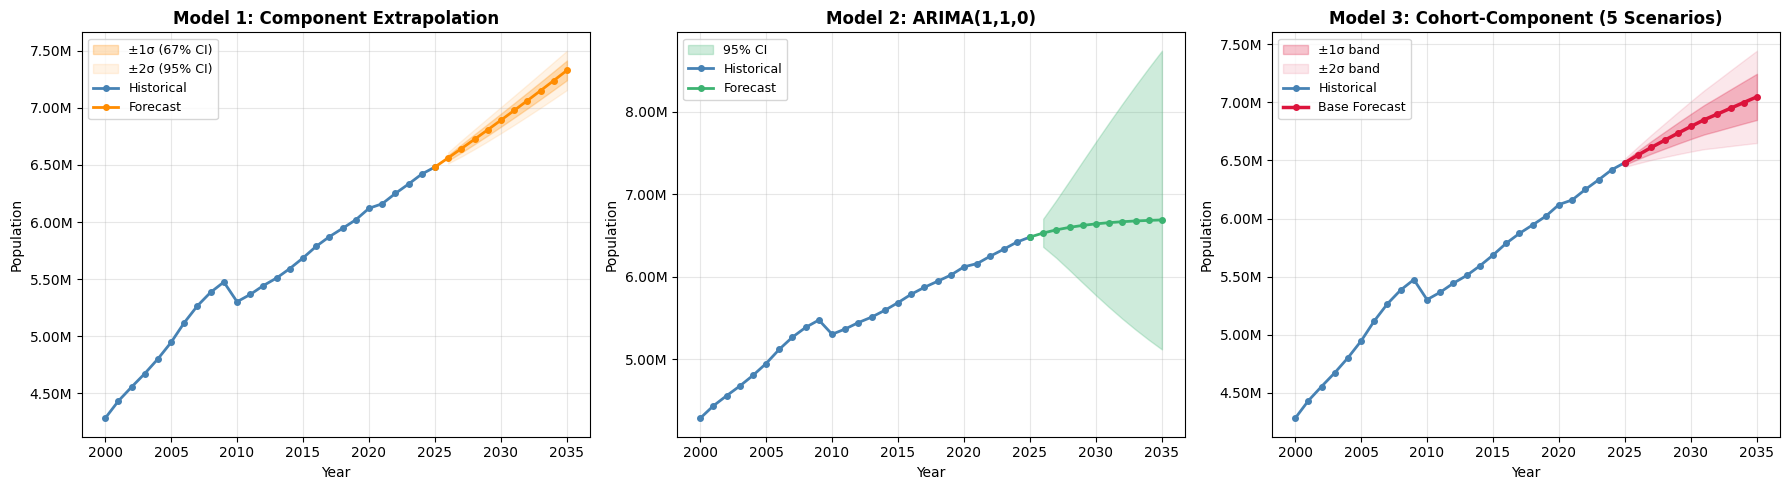


✓ Model comparison visualization saved as 'model_comparison.png'


In [29]:
# Create 3-panel visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Historical data for all models
hist_years = df["YEAR"].values
hist_pop = df["POP_ESTIMATE"].values

# =====================
# PANEL 1: Model 1 (Extrapolation)
# =====================
ax = axes[0]
ax.fill_between(model1_df["YEAR"], model1_df["POP_1S_LOW"], model1_df["POP_1S_UP"], 
                alpha=0.25, color='darkorange', label='±1σ (67% CI)', zorder=2)
ax.fill_between(model1_df["YEAR"], model1_df["POP_2S_LOW"], model1_df["POP_2S_UP"], 
                alpha=0.10, color='darkorange', label='±2σ (95% CI)', zorder=1)
ax.plot(hist_years, hist_pop, 'o-', color='steelblue', linewidth=2, markersize=4, label='Historical', zorder=3)
# Connect to forecast smoothly
forecast_years_ext1 = np.concatenate([[hist_years[-1]], model1_df["YEAR"].values])
forecast_pop_ext1 = np.concatenate([[hist_pop[-1]], model1_df["POP_ESTIMATE"].values])
ax.plot(forecast_years_ext1, forecast_pop_ext1, 'o-', color='darkorange', linewidth=2, markersize=4, label='Forecast', zorder=3)
ax.set_title('Model 1: Component Extrapolation', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Population')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))

# =====================
# PANEL 2: Model 2 (ARIMA)
# =====================
ax = axes[1]
ax.fill_between(model2_df["YEAR"], model2_df["LOWER_95"], model2_df["UPPER_95"], 
                alpha=0.25, color='mediumseagreen', label='95% CI', zorder=2)
ax.plot(hist_years, hist_pop, 'o-', color='steelblue', linewidth=2, markersize=4, label='Historical', zorder=3)
# Connect to forecast smoothly
forecast_years_ext2 = np.concatenate([[hist_years[-1]], model2_df["YEAR"].values])
forecast_pop_ext2 = np.concatenate([[hist_pop[-1]], model2_df["POP_ESTIMATE"].values])
ax.plot(forecast_years_ext2, forecast_pop_ext2, 'o-', color='mediumseagreen', linewidth=2, markersize=4, label='Forecast', zorder=3)
ax.set_title('Model 2: ARIMA(1,1,0)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Population')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))

# =====================
# PANEL 3: Model 3 (Cohort-Component with Scenarios)
# =====================
ax = axes[2]
ax.fill_between(scenarios_df.index, scenarios_df['low'], scenarios_df['high'], 
                alpha=0.25, color='crimson', label='±1σ band', zorder=2)
ax.fill_between(scenarios_df.index, scenarios_df['vlow'], scenarios_df['vhigh'], 
                alpha=0.10, color='crimson', label='±2σ band', zorder=1)
ax.plot(hist_years, hist_pop, 'o-', color='steelblue', linewidth=2, markersize=4, label='Historical', zorder=3)
ax.plot(scenarios_df.index, scenarios_df['base'], 'o-', color='crimson', linewidth=2.5, markersize=4, label='Base Forecast', zorder=3)
ax.set_title('Model 3: Cohort-Component (5 Scenarios)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Population')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison visualization saved as 'model_comparison.png'")

---

## Section 5: Key Insights and Model Selection

### Why Model 3 (Cohort-Component) is Recommended

**Strengths:**
1. **Demographically valid** — Respects cohort aging, age-specific rates
2. **Interpretable** — Each component (fertility, mortality, migration) is explicit
3. **Flexible** — Easily incorporate policy changes (e.g., migration restrictions)
4. **Detailed outputs** — Age structure of future population (not just total)
5. **Validated** — Tested against historical observed deaths (2020-2024)

**Limitations:**
- More complex — requires more data and assumptions
- Sensitive to both fertility and mortality assumptions
- Age 85+ requires special treatment (geometric trend)

### Model Uncertainty: What Drives Forecast Bands?

- **Model 1**: Uncertainty grows as $$\sigma_t = \sigma_g \sqrt{t}$$ (time-dependent)
- **Model 2**: ARIMA CI widenslarge due to short time series (n=26) and structural breaks
- **Model 3**: Scenarios capture migration variability (dominant uncertainty source)

**Key finding**: **Migration is the primary driver of variability**, far exceeding birth/death fluctuations. This is why we create 5 migration scenarios ($$\mu \pm 2\sigma$$).

### Structural Breaks to Monitor

The historical data shows:
- **2007-2012**: Recession → reduced in-migration (structural break)
- **2020-2021**: Pandemic → remote work enabled relocation boom
- **2022-2024**: Recovery and stabilization

**Assumption**: We assume reversion to historical mean migration. If structural factors persist (e.g., remote work), scenarios may underestimate uncertainty.

---

## Section 6: Export Results

Export all model outputs to Excel for further analysis and presentation.


In [30]:
print("\n" + "=" * 70)
print("EXPORT RESULTS")
print("=" * 70)

# Create Excel writer
output_file = "population_forecasts_atlanta_msa.xlsx"
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Model 1 Results
    model1_df.to_excel(writer, sheet_name='Model 1 - Extrapolation', index=False)
    print(f"✓ Model 1 exported ({len(model1_df)} rows)")
    
    # Model 2 Results
    model2_df.to_excel(writer, sheet_name='Model 2 - ARIMA', index=False)
    print(f"✓ Model 2 exported ({len(model2_df)} rows)")
    
    # Model 3 Results
    yearly_model3.to_excel(writer, sheet_name='Model 3 - Cohort Base', index=False)
    print(f"✓ Model 3 Base scenario exported ({len(yearly_model3)} rows)")
    
    # All scenarios
    scenarios_df.to_excel(writer, sheet_name='Model 3 - All Scenarios')
    print(f"✓ Model 3 All scenarios exported ({len(scenarios_df)} rows)")
    
    # Comparison
    comparison.to_excel(writer, sheet_name='Model Comparison', index=False)
    print(f"✓ Model comparison summary exported")

print(f"\n✓ All results saved to: {output_file}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print(f"\nRecommendation: Use Model 3 (Cohort-Component) for planning purposes.")
print(f"  • Base scenario: {yearly_model3.iloc[-1]['POP_ESTIMATE']:,.0f} (2035)")
print(f"  • Range (Model 3): {scenarios_df.loc[2035, 'vlow']:,.0f} to {scenarios_df.loc[2035, 'vhigh']:,.0f}")
print(f"  • Growth 2024-2035: {((yearly_model3.iloc[-1]['POP_ESTIMATE'] / baseline_2024) - 1) * 100:.1f}%")


EXPORT RESULTS
✓ Model 1 exported (10 rows)
✓ Model 2 exported (10 rows)
✓ Model 3 Base scenario exported (11 rows)
✓ Model 3 All scenarios exported (11 rows)
✓ Model comparison summary exported

✓ All results saved to: population_forecasts_atlanta_msa.xlsx

ANALYSIS COMPLETE

Recommendation: Use Model 3 (Cohort-Component) for planning purposes.
  • Base scenario: 7,047,026 (2035)
  • Range (Model 3): 6,650,115 to 7,443,936
  • Growth 2024-2035: 8.7%


---

## Appendix: Glossary of Demographic Terms

### Population Components

- **Birth Rate** ($b_t$): Births per capita in year t, $b_t = B_t / P_t$
- **Death Rate** ($d_t$): Deaths per capita, $d_t = D_t / P_t$
- **Net Migration Rate** ($m_t$): (International + Domestic migration) per capita
- **Residual Rate** ($r_t$): Unexplained population change per capita
- **Growth Rate** ($g$): Combined component rate, $g = b - d + m_{int} + m_{dom} + r$

### Age-Specific Rates

- **Fertility Distribution** ($p_a$): Probability of birth at age a, $\sum p_a = 1$
- **Mortality Rate** ($m(x)$): Fraction of age-x cohort who die (incremental), $m(x) = m̂_x - m̂_{x-1}$
- **Gompertz Model**: $\log(m_x) = \alpha + \beta x$, captures exponential mortality increase with age

### Time Series Methods

- **Stationarity**: Mean and variance of series constant over time
- **ADF Test**: Augmented Dickey-Fuller test for unit root (non-stationarity)
- **Differencing**: $\Delta Y_t = Y_t - Y_{t-1}$, removes trends
- **ARIMA(p,d,q)**: AR=p lags, I=d differences, MA=q moving average
- **Log Transform**: $Y = \log(P)$, linearizes exponential growth

### Uncertainty Measures

- **Standard Deviation** ($\sigma$): Spread of historical variation
- **Confidence Interval (CI)**:
  - **67% CI**: $\pm 1\sigma$ under normality
  - **95% CI**: $\pm 2\sigma$ under normality
- **Scenario Analysis**: $\mu \pm k\sigma$ for $k \in \{0, 1, 2\}$

### Demographic Indicators

- **CAGR**: Compound Annual Growth Rate, $\text{CAGR} = (P_{\text{end}}/P_{\text{start}})^{1/n} - 1$
- **Cohort**: Age group born in same year; ages forward one year per calendar year
- **Open-Ended Age Group**: Age 85+ (ungrouped people 85 and older)
- **Female Ratio**: $r_f = F_{\text{total}} / P_{\text{total}}$, typically ~0.51

---

## References and Further Reading

1. **Cohort-Component Models**: Preston, Heuveline & Guillot (2001), "Demography: Measuring and Modeling Population Processes"
2. **Gompertz Mortality**: Gompertz, B. (1825), "On the nature of the function expressive of the law of human mortality"
3. **ARIMA**: Box & Jenkins (1976), "Time Series Analysis: Forecasting and Control"
4. **Population Projections**: UN World Population Prospects (annual)

---

### Notes

- **Data Source**: Final_Data_for_Modeling.xlsx with Atlanta MSA (CBSA 12060)
- **Projection Horizon**: 2025-2035 (10 years)
- **Historical Baseline**: 2024 census estimate
- **Last Updated**: 2026-04-14
